# 04 — Métricas adicionales del cliente

Recencia (días desde la última compra), AOV (ticket medio) y tasa de devolución.

## 0. Setup

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ROOT = Path('..')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
PALETTE = sns.color_palette('crest', as_cmap=False)

## 1. Cálculo de métricas

In [3]:
%%sql
with ventas as (
    select  f.customer_sk,
            sum(f.subtotal)                                 as gross_revenue,
            sum(f.subtotal - coalesce(r.returned_value,0))  as net_revenue,
            sum(coalesce(r.returned_value,0))               as returned_value,
            count(distinct f.sale_id)                       as frequency,
            max(d.full_date)                                as last_purchase
    from dwh.fact_sales f
    join dwh.dim_date d on d.date_id = f.sale_date_id
    left join (
        select sale_item_id, sum(returned_value) as returned_value
        from dwh.fact_returns
        group by sale_item_id
    ) r on r.sale_item_id = f.sale_item_id
    group by f.customer_sk
),
ref as (select max(full_date) as today from dwh.dim_date d
        where exists (select 1 from dwh.fact_sales f where f.sale_date_id = d.date_id))
select  c.customer_sk,
        c.customer_id,
        v.gross_revenue,
        v.net_revenue,
        v.returned_value,
        v.frequency,
        v.last_purchase,
        case when v.frequency > 0 then v.net_revenue / v.frequency else 0 end as aov,
        (ref.today::date - v.last_purchase::date)::int                          as recency_days,
        case when v.gross_revenue > 0 then v.returned_value / v.gross_revenue else 0 end as return_rate
from ventas v
join dwh.dim_customer c on c.customer_sk = v.customer_sk
cross join ref

,customer_sk,customer_id,gross_revenue,net_revenue,returned_value,frequency,last_purchase,aov,recency_days,return_rate
0,1,1,11740.55,11510.66,229.89,22,2025-10-01,523.211818,90,0.019581
1,2,2,12744.26,12429.59,314.67,24,2025-10-30,517.899583,61,0.024691
2,3,3,19862.51,19416.56,445.95,24,2025-11-07,809.023333,53,0.022452
3,4,4,8203.76,7993.78,209.98,10,2025-12-12,799.378000,18,0.025596
4,5,5,10938.05,10578.18,359.87,22,2025-12-07,480.826364,23,0.032901
...,...,...,...,...,...,...,...,...,...,...
5745,5746,5748,34.99,34.99,0.00,1,2023-08-03,34.990000,880,0.000000
5746,5747,5749,59.99,0.00,59.99,1,2022-04-12,0.000000,1358,1.000000
5747,5748,5750,139.99,139.99,0.00,1,2025-09-08,139.990000,113,0.000000
5748,5749,5751,1199.97,1199.97,0.00,1,2023-07-02,1199.970000,912,0.000000


## 2. Estadística descriptiva

In [4]:
metrics[['gross_revenue','net_revenue','aov','recency_days',
         'return_rate','frequency']].describe().round(2)

,gross_revenue,net_revenue,aov,recency_days,return_rate,frequency
count,5750.00,5750.00,5750.00,5750.00,5750.00,5750.00
mean,1683.26,1635.20,210.04,673.46,0.07,3.48
std,4090.00,3989.09,204.07,601.07,0.24,6.59
min,19.99,-179.99,-179.99,0.00,0.00,1.00
25%,79.80,59.99,59.99,92.00,0.00,1.00
50%,149.90,129.99,129.99,421.00,0.00,1.00
75%,299.99,299.99,299.99,1299.75,0.00,1.00
max,24922.00,23932.15,1199.97,1824.00,2.00,34.00


## 3. Distribución de cada métrica

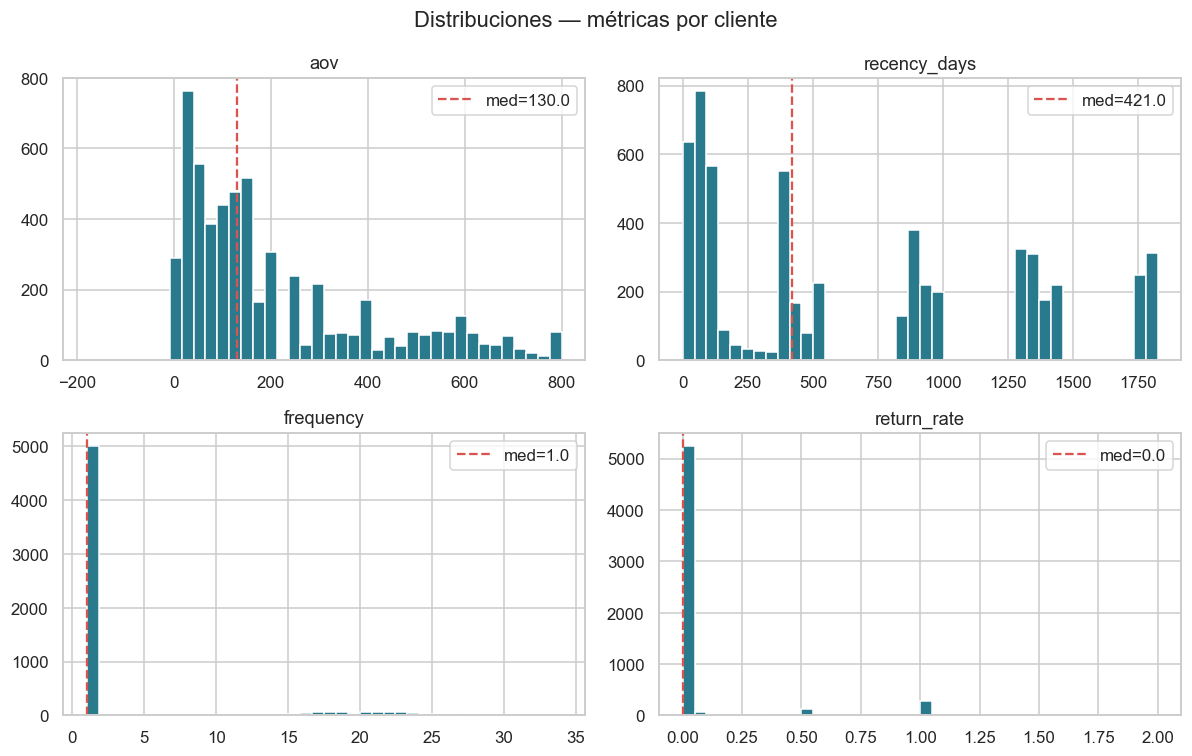

In [5]:
cols = ['aov','recency_days','frequency','return_rate']
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, c in zip(axes.flatten(), cols):
    s = metrics[c].astype(float).dropna()
    s = s.clip(upper=s.quantile(0.99)) if c in ('aov',) else s
    ax.hist(s, bins=40, color=PALETTE[3], edgecolor='white')
    ax.axvline(s.median(), color='#d9534f', ls='--', label=f'med={s.median():.1f}')
    ax.set_title(c)
    ax.legend()
plt.suptitle('Distribuciones — métricas por cliente')
plt.tight_layout()
plt.show()

## 4. Recencia vs frecuencia (RFM lite)

Color por ingresos netos: revela los segmentos *high value / dormant*.

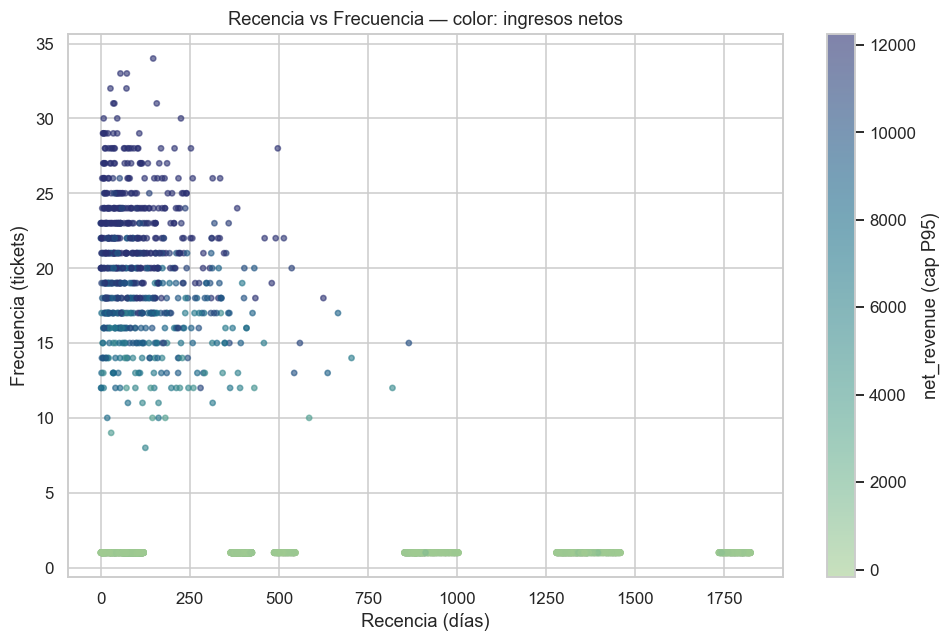

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(metrics['recency_days'], metrics['frequency'],
                c=metrics['net_revenue'].clip(upper=metrics['net_revenue'].quantile(0.95)),
                cmap='crest', s=12, alpha=0.6)
ax.set_xlabel('Recencia (días)')
ax.set_ylabel('Frecuencia (tickets)')
ax.set_title('Recencia vs Frecuencia — color: ingresos netos')
plt.colorbar(sc, label='net_revenue (cap P95)')
plt.tight_layout()
plt.show()

## 5. AOV por decil de ingresos

Confirma si los clientes que más gastan también tienen tickets de mayor importe.

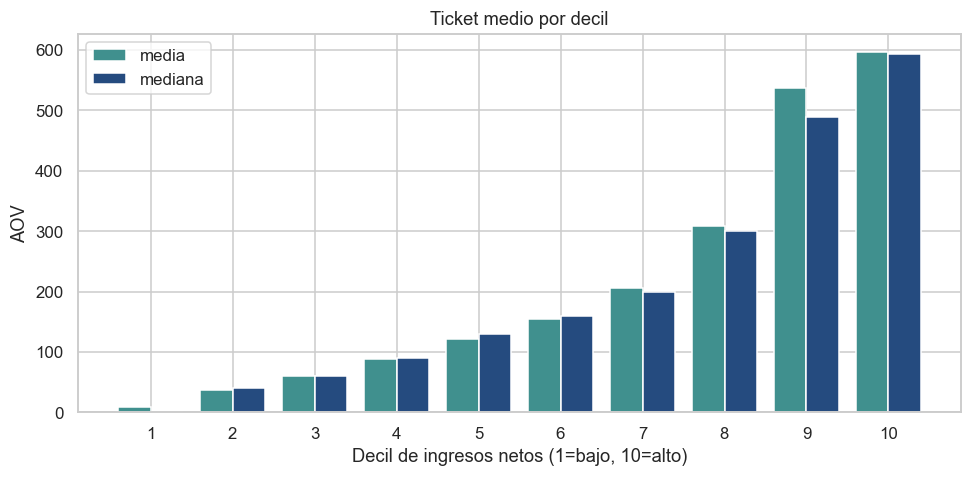

,aov_mean,aov_median,n
rev_decile,,,
1,9.44,0.00,578
2,37.10,39.90,578
3,60.51,59.99,582
4,87.80,89.90,597
5,121.53,129.90,584
6,154.57,159.98,539
7,205.06,199.90,588
8,308.12,299.99,571
9,536.28,488.77,558


In [7]:
metrics_q = metrics.assign(
    rev_decile=pd.qcut(metrics['net_revenue'], 10, duplicates='drop', labels=False) + 1
)
agg = metrics_q.groupby('rev_decile').agg(
    aov_mean=('aov','mean'),
    aov_median=('aov','median'),
    n=('aov','size')
).round(2)

fig, ax = plt.subplots(figsize=(9, 4.5))
x = agg.index
ax.bar(x - 0.2, agg['aov_mean'],   width=0.4, label='media',   color=PALETTE[2])
ax.bar(x + 0.2, agg['aov_median'], width=0.4, label='mediana', color=PALETTE[5])
ax.set_xlabel('Decil de ingresos netos (1=bajo, 10=alto)')
ax.set_ylabel('AOV')
ax.set_title('Ticket medio por decil')
ax.set_xticks(list(x))
ax.legend()
plt.tight_layout()
plt.show()

agg

## 6. Tasa de devolución por decil de frecuencia

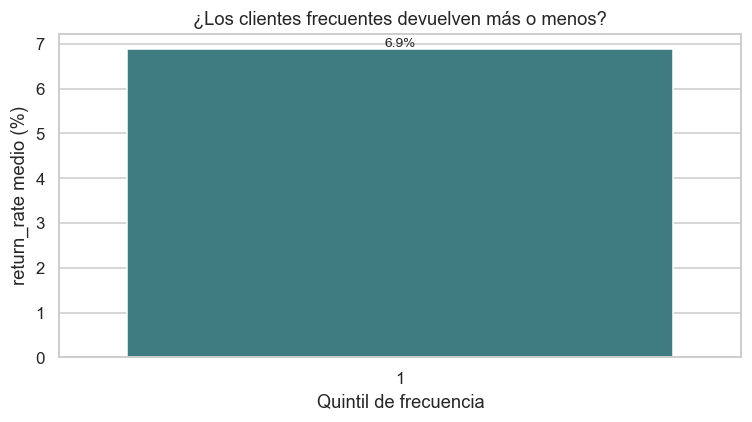

In [8]:
metrics_qf = metrics.assign(
    freq_decile=pd.qcut(metrics['frequency'], 5, duplicates='drop', labels=False) + 1
)
rr = metrics_qf.groupby('freq_decile')['return_rate'].mean().mul(100).round(2)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=rr.index.astype(int), y=rr.values, hue=rr.index.astype(int),
            palette='crest', ax=ax, legend=False)
ax.set_xlabel('Quintil de frecuencia')
ax.set_ylabel('return_rate medio (%)')
ax.set_title('¿Los clientes frecuentes devuelven más o menos?')
for i, v in enumerate(rr.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Correlaciones entre métricas

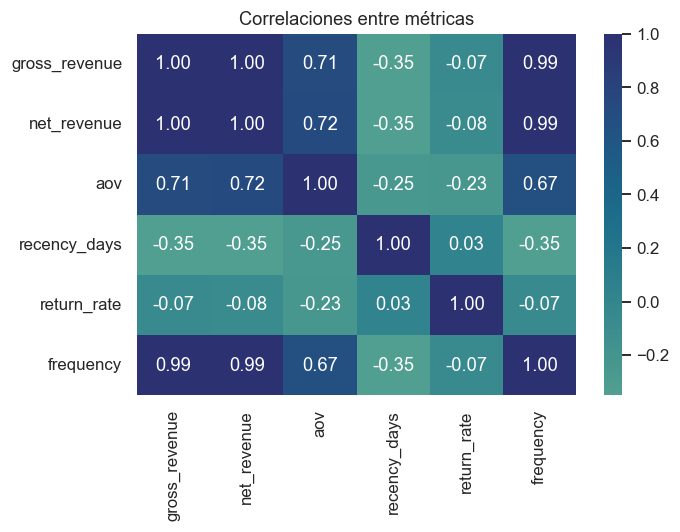

In [9]:
corr = metrics[['gross_revenue','net_revenue','aov','recency_days',
                'return_rate','frequency']].corr().round(2)
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='crest', center=0, ax=ax)
ax.set_title('Correlaciones entre métricas')
plt.tight_layout()
plt.show()

## 8. Persistencia

In [10]:
out = ROOT / 'data' / 'processed' / 'customer_metrics.parquet'
out.parent.mkdir(parents=True, exist_ok=True)
metrics.to_parquet(out, index=False)
out

PosixPath('../data/processed/customer_metrics.parquet')